# 🎨 Pixel Manipulation & 3D Color Images
### Tasks:
1. Manipulate pixel values — open image, locate top-left corner, change pixels to `0`
2. Create a 3D image using colors


In [310]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

## Task 1 · Manipulate Pixel Values
Open an image, locate the top-left corner, and change those pixel values to `0` (black).


In [3]:
# Open the image
img = Image.open("redbull.jpg")
arr = np.array(img).copy()   # .copy() so we don't modify the original

print(f"Image size : {img.size}")
print(f"Array shape: {arr.shape}")


Image size : (1500, 888)
Array shape: (888, 1500, 3)


In [4]:
# Before — top-left 5x5 pixel values
print("Before (top-left 5×5 pixels):")
print(arr[:5, :5])


Before (top-left 5×5 pixels):
[[[ 9 41 52]
  [ 6 36 47]
  [ 1 27 40]
  [ 0 23 35]
  [ 1 20 34]]

 [[10 42 53]
  [ 6 36 47]
  [ 2 28 41]
  [ 0 23 35]
  [ 1 20 34]]

 [[11 43 54]
  [ 7 37 48]
  [ 2 29 40]
  [ 0 23 35]
  [ 1 20 34]]

 [[12 44 55]
  [ 8 38 49]
  [ 3 30 41]
  [ 0 24 36]
  [ 1 20 34]]

 [[12 44 55]
  [ 8 38 49]
  [ 2 30 41]
  [ 0 24 36]
  [ 1 20 34]]]


In [5]:
# Change top-left 50×50 corner to 0 (black)
arr[:50, :50] = 0

print("After (top-left 5×5 pixels):")
print(arr[:5, :5])


After (top-left 5×5 pixels):
[[[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


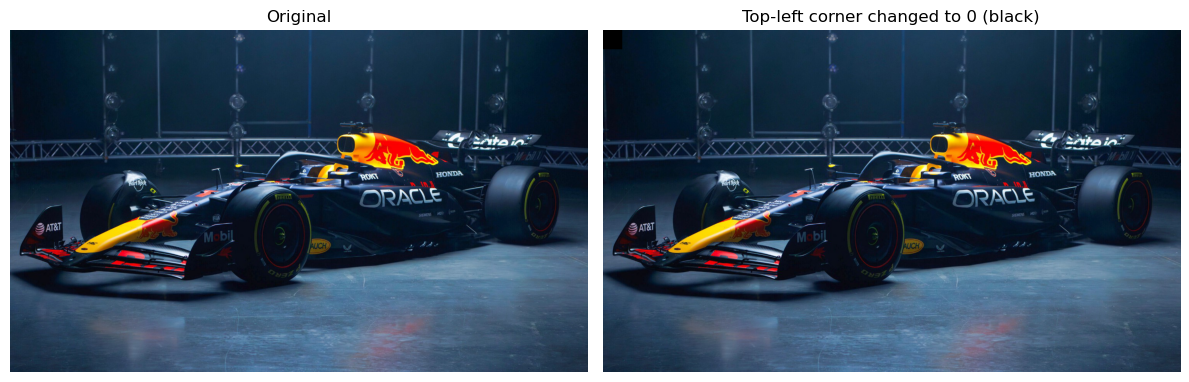

In [6]:
# Display before and after side by side
img_modified = Image.fromarray(arr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_modified)
axes[1].set_title("Top-left corner changed to 0 (black)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">


### Observation
The top-left corner of the image is now black because we set all pixel values in that region to `[0, 0, 0]`.  
The rest of the image is unchanged since we used `.copy()` to avoid modifying the original array.


## Task 2 · Create a 3D Image Using Colors
A 3D array has shape `(height, width, channels)` where channels = 3 for RGB.


In [33]:
# Create a 20×20 black canvas with 3 channels (R, G, B)
n  = 20
r  = n // 2   # midpoint = 10
arr_3d = np.zeros((n, n, 3), dtype=np.uint8)

print(f"Array shape: {arr_3d.shape}")
print(f"Total values: {arr_3d.size}")


Array shape: (20, 20, 3)
Total values: 1200


### American Flag


In [304]:
def show_image(arr):
    plt.imshow(arr)
    plt.axis("off")
    plt.show()

In [308]:
def save_image(arr,name):
    img = Image.fromarray(arr)
    img.save(name+".jpg")
    print("Image has been successfully saved!") 

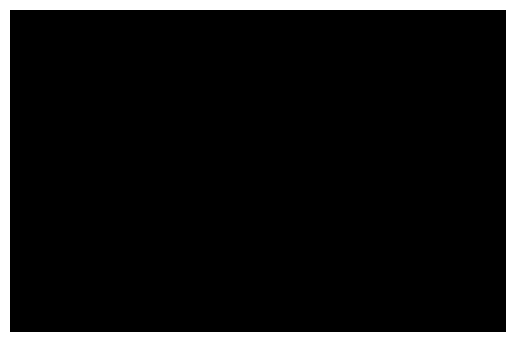

In [300]:
height, width = 65,100
flag = np.zeros((height, width, 3), dtype=np.uint8)
show_image(flag)

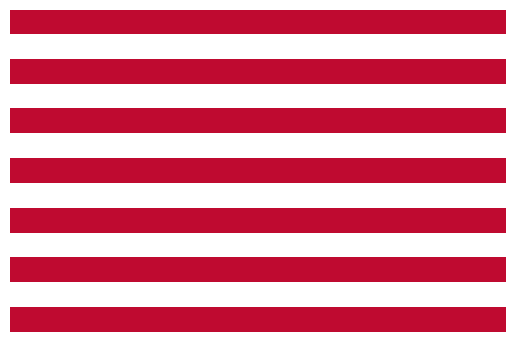

In [301]:
# Every other row — red and white stripes
# american fflag has 13 stripes 
stripe_h = height // 13
for i in range(13):
    color = [191, 10, 48] if i % 2 == 0 else [255, 255, 255]
    flag[i*stripe_h:(i+1)*stripe_h, :] = color
show_image(flag)

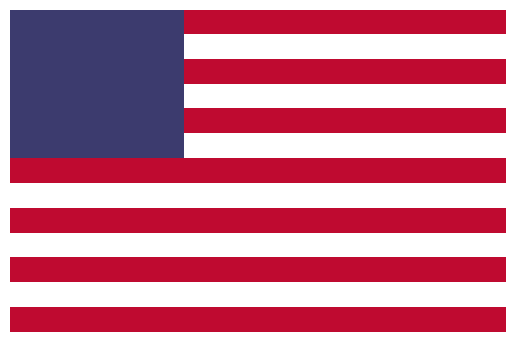

In [302]:
# Add the blue section in top left part 
bh =6 * stripe_h   # 35
bw = 35
flag[:bh, :bw] = [60, 59, 110]
show_image(flag)

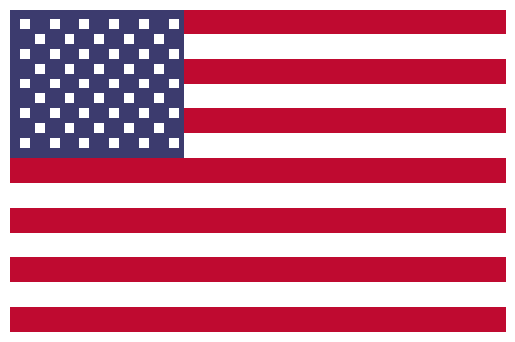

In [303]:
# 5 rows of 6 stars
for row in range(5):
    for col in range(6):
        r = 2 + row * 6
        c = 2 + col * 6
        flag[r:r+2, c:c+2] = [255, 255, 255]

# 4 rows of 5 stars (offset)
for row in range(4):
    for col in range(5):
        r = 5 + row * 6
        c = 5 + col * 6
        flag[r:r+2, c:c+2] = [255, 255, 255]
show_image(flag)

In [309]:
save_image(flag,"flag")

Image has been successfully saved!


**Rule of thumb:**
```
top-left     → [0, 0]
top-right    → [0, width]
bottom-left  → [height, 0]
bottom-right → [height, width]
center       → [height//2, width//2]

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">

## Observation: Building the American Flag from Pixels

### Stripes
- 13 stripes created using `stripe_h = height // 13`, alternating **Old Glory Red** `[191, 10, 48]` and white `[255, 255, 255]`
- Each stripe is exactly 5 pixels tall, filling the full width of the flag

### Blue Canton
- Placed using `flag[:bh, :bw]` covering the top-left corner
- Height = 5 stripe heights, width = 35 pixels to match real flag proportions
- Color `[60, 59, 110]` matches the deep navy blue of the real flag

### Stars
- 50 stars in alternating rows — **5 rows of 6** and **4 rows of 5**
- Generated using a formula instead of hardcoded positions
- Each star is a `2×2` white pixel box `[255, 255, 255]`

### Pixel Color Reference
| Region | RGB Value |
|--------|-----------|
| Red stripes | `[191, 10, 48]` |
| White stripes | `[255, 255, 255]` |
| Blue canton | `[60, 59, 110]` |
| Stars | `[255, 255, 255]` |

### Challenges
- Blue canton size required trial and error to balance star spacing
- Stars needed precise row/column offsets to fit inside canton without overflowing